# Set Up

En este notebook se compara contra la epoca 15, y se toma como referencia los valores del famfold que yo mismo obtuve

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# plt.rc("text", usetex=True)
# plt.rc("font", family="serif")

In [7]:
experiments = [
    "hc_100",
    "hc_200",
    "hc_400",
    "rnadist_100",
    "rnadist_200",
    "rnadist_400",
    "samples_100",
    "samples_200",
    "samples_400",
]

In [10]:
def get_data(PATH):
    df = pd.read_csv(PATH, index_col=0)
    df.reset_index(inplace=True)
    df.rename(columns={"index": "fam"}, inplace=True)
    df_ref = df[["fam", "famfold"]]
    df_ref.sort_values(by="fam", ascending=False, inplace=True)
    df.drop(columns=["famfold"], inplace=True)
    return df, df_ref

SILVER_PATH = "/home/gkulemeyer/Documents/Repos/RNA-analysis/Experiments/f_ArchiveII/REDFold/SILVER/"
DATA_PATH = "200_epochs_test.csv"
df, df_ref = get_data(SILVER_PATH + DATA_PATH)

display(df)
display(df_ref)

/tmp/ipykernel_2728643/30159048.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ref.sort_values(by="fam", ascending=False, inplace=True)


,fam,hc_100,hc_200,hc_400,rnadist_100,rnadist_200,rnadist_400,samples_100,samples_200,samples_400
0,16s,0.307474,0.361817,0.369151,0.361907,0.357176,0.367012,0.345676,0.382140,0.374577
1,23s,0.386905,0.397000,0.369966,0.375097,0.303304,0.357323,0.365386,0.390262,0.426000
2,5s,0.443412,0.439030,0.428794,0.467526,0.467356,0.452008,0.466343,0.485948,0.465358
3,RNaseP,0.247857,0.377613,0.386236,0.325726,0.378033,0.388110,0.335546,0.315993,0.393932
4,grp1,0.330637,0.387894,0.355659,0.350830,0.324978,0.353661,0.353017,0.320431,0.392255
5,srp,0.225801,0.205541,0.175389,0.217280,0.218331,0.188988,0.201441,0.221099,0.171035
6,tRNA,0.558926,0.581677,0.573349,0.552531,0.506898,0.528507,0.502785,0.517630,0.534651
7,telomerase,0.115338,0.122411,0.131918,0.103230,0.085112,0.139342,0.110304,0.103004,0.131605
8,tmRNA,0.314966,0.354786,0.376782,0.339647,0.263739,0.357534,0.326804,0.229740,0.336478


,fam,famfold
8,tmRNA,0.333408
7,telomerase,0.118316
6,tRNA,0.542763
5,srp,0.195454
4,grp1,0.387848
3,RNaseP,0.379064
2,5s,0.484213
1,23s,0.365124
0,16s,0.349758


In [11]:
df_ref.set_index("fam")["famfold"].to_dict()
def normalizar_y_melt(df, rna_llm, experiments):
    rna_llm_series = pd.Series(rna_llm.set_index("fam")["famfold"].to_dict())
    df_norm = df.copy()
    cols_to_normalize = [col for col in df.columns if col != "fam"]

    # Normalizar cada columna (vectorizado)
    df_norm[cols_to_normalize] = df_norm[cols_to_normalize].div(
        df_norm["fam"].map(rna_llm_series), axis=0
    )

    # Transformar a formato long
    dfn = df_norm.melt(
        id_vars="fam",
        value_vars=experiments,
        var_name="modelo",
        value_name="f1",
    )

    return dfn


def add_metodo_umbral(df: pd.DataFrame) -> pd.DataFrame:
    """Desglosa 'modelo' → ['metodo', 'umbral'] (string)."""
    out = df.copy()
    out[["metodo", "umbral"]] = out["modelo"].str.extract(r"([A-Za-z]+)_(\d+)")
    out["umbral"] = out["umbral"].astype(str)
    return out


# Transformar a formato long
dfl = df.melt(
    id_vars="fam",
    value_vars=experiments,
    var_name="modelo",
    value_name="f1",
)
dfn = normalizar_y_melt(df, df_ref, experiments)

In [12]:
s = dfn.groupby("modelo")["f1"].mean().sort_values().reset_index()
s = s.rename(columns={"f1": "rel_f1"})
s.to_csv(SILVER_PATH + "/200_epochs_relf1.csv")
s

,modelo,rel_f1
0,rnadist_200,0.912625
1,hc_100,0.940601
2,samples_200,0.941039
3,samples_100,0.957442
4,rnadist_100,0.979145
5,rnadist_400,1.009766
6,hc_400,1.009881
7,samples_400,1.025665
8,hc_200,1.027422


In [13]:
PALETTE = {"100": "#1B9E77", "200": "#D95F02", "400": "#7570B3"}
MARKERS = {"hc": "*", "samples": "o", "rnadist": "^"}


dfl = add_metodo_umbral(dfl)  # absolutos
dfn = add_metodo_umbral(dfn)  # normalizados


# plot utils
def strip(ax, df, fam_map, seed=0):
    """Scatter categórico con jitter: color=umbral, marker=método."""
    # jitter
    rng = np.random.default_rng(seed)
    x = df["fam"].map(fam_map) + rng.uniform(-0.25, 0.25, len(df["fam"]))
    # plot
    for metodo, g in df.groupby("metodo"):
        ax.scatter(
            x[g.index],
            g["f1"],
            marker=MARKERS.get(metodo, "o"),
            c=[PALETTE[u] for u in g["umbral"]],
            edgecolors="k",
            lw=0.5,
            s=60,
            alpha=0.75,
            label=metodo,
        )


def combined_legend(fig, axes):
    """Leyenda única (métodos + umbrales) sin duplicados."""
    handles, labels = [], []
    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        handles += h
        labels += l
        if ax.get_legend():
            ax.get_legend().remove()

    color_handles = [
        Line2D([0], [0], marker="D", ls="", color=PALETTE[u], label=u) for u in PALETTE
    ]
    handles += color_handles
    labels += [h.get_label() for h in color_handles]

    uniq = dict(zip(labels, handles))
    fig.legend(uniq.values(), uniq.keys(), loc="lower center", ncol=5, frameon=False)

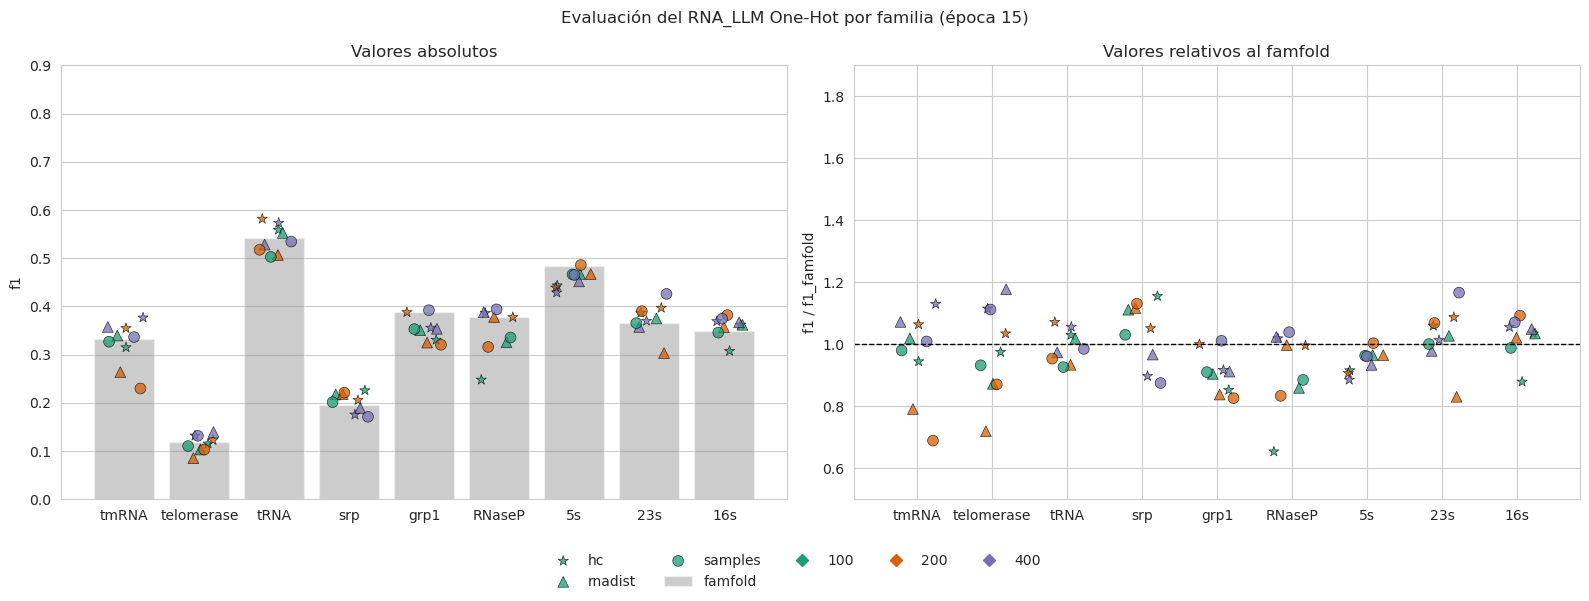

In [ ]:
fam_order = sorted(dfl["fam"].unique(), reverse=True)
fam_map = {f: i for i, f in enumerate(fam_order)}

# ────────────── PLOT ──────────────
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

# Panel A: valores absolutos
sns.barplot(
    data=df_ref,
    x="fam",
    y="famfold",
    color="gray",
    alpha=0.4,
    errorbar=None,
    ax=axes[0],
    label="famfold",
)
strip(axes[0], dfl, fam_map)
axes[0].set_ylim(0, 0.9)
axes[0].set_title("Valores absolutos")
axes[0].set_ylabel("f1")

# Panel B: valores relativos
strip(axes[1], dfn, fam_map)
axes[1].axhline(1, ls="--", lw=1, color="k")
axes[1].set_ylim(0.5, 1.9)
axes[1].set_title("Valores relativos al famfold")
axes[1].set_ylabel("f1 / f1_famfold")

# Etiquetas comunes
for ax in axes:
    ax.set_xlabel("")
    ax.set_xticks(range(len(fam_order)))
    ax.set_xticklabels(fam_order)

fig.suptitle("Evaluación del REDFold por familia (época 200)")
combined_legend(fig, axes)

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

In [15]:
print(dfl)

           fam       modelo        f1   metodo umbral
0          16s       hc_100  0.307474       hc    100
1          23s       hc_100  0.386905       hc    100
2           5s       hc_100  0.443412       hc    100
3       RNaseP       hc_100  0.247857       hc    100
4         grp1       hc_100  0.330637       hc    100
..         ...          ...       ...      ...    ...
76        grp1  samples_400  0.392255  samples    400
77         srp  samples_400  0.171035  samples    400
78        tRNA  samples_400  0.534651  samples    400
79  telomerase  samples_400  0.131605  samples    400
80       tmRNA  samples_400  0.336478  samples    400

[81 rows x 5 columns]
